# Week 1 — Polynomial and Interaction Terms (Regression)

**Two datasets, one analysis.** This notebook loads the **Credit Risk** (Kaggle, ~29k applications) and
**Statlog German Credit** (UCI, 1,000 applications) datasets together and applies every Week 1
technique to **both**, with matching visualizations, so the two can be compared head to head.
Credit Risk models the **interest rate**; German Credit models **log(credit amount)**. Both are continuous targets.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(11,4); pd.set_option('display.max_columns',60)
RANDOM_STATE = 42
DATASETS = ['Credit Risk', 'German Credit']
PALETTE = {'Credit Risk':'#4c72b0', 'German Credit':'#55a467'}

# ---------- Credit Risk ----------
def _credit_risk():
    df = pd.read_csv('credit_risk_dataset.csv')
    df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
    df = df[df['person_age'] <= 80]
    df = df[df['person_emp_length'].fillna(0) <= 60]
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_grade_ord'] = df['loan_grade'].map({g:i+1 for i,g in enumerate(list('ABCDEFG'))})
    df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
    df['log_income'] = np.log(df['person_income'])
    df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True, dtype=int)
    num = ['person_age','log_income','person_emp_length','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
    base = num + ['loan_grade_ord','default_on_file'] + [c for c in df.columns if c.startswith('person_home_ownership_') or c.startswith('loan_intent_')]
    return dict(df=df, num=num, poly=['person_age','loan_amnt','cb_person_cred_hist_length'],
                reg_target='loan_int_rate', reg_label='interest rate (%)', reg_feats=base,
                clf_target='loan_status', clf_pos='default', clf_feats=base+['loan_int_rate'])

# ---------- German Credit ----------
def _german():
    rename={'Attribute1':'checking_status','Attribute2':'duration_months','Attribute3':'credit_history',
     'Attribute4':'purpose','Attribute5':'credit_amount','Attribute6':'savings_status','Attribute7':'employment_since',
     'Attribute8':'installment_rate','Attribute9':'personal_status_sex','Attribute10':'other_debtors',
     'Attribute11':'residence_since','Attribute12':'property','Attribute13':'age_years','Attribute14':'other_installment_plans',
     'Attribute15':'housing','Attribute16':'existing_credits','Attribute17':'job','Attribute18':'num_dependents',
     'Attribute19':'telephone','Attribute20':'foreign_worker','class':'target'}
    df = pd.read_csv('german_credit_data.csv').rename(columns=rename)
    df['bad'] = (df['target'] == 2).astype(int); df = df.drop(columns=['target'])
    df['log_credit_amount'] = np.log(df['credit_amount'])
    num = ['duration_months','installment_rate','residence_since','age_years','existing_credits','num_dependents']
    cat = ['checking_status','credit_history','purpose','savings_status','employment_since','personal_status_sex',
           'other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
    dfd = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)
    reg_feats = num + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)] + ['bad']
    clf_feats = num + ['credit_amount'] + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)]
    return dict(df=dfd, raw=df, num=num, poly=['duration_months','age_years','installment_rate'],
                reg_target='log_credit_amount', reg_label='log(credit amount)', reg_feats=reg_feats,
                clf_target='bad', clf_pos='bad credit', clf_feats=clf_feats)

_CACHE = {'Credit Risk':_credit_risk(), 'German Credit':_german()}

def reg_design(name):
    c=_CACHE[name]; X=c['df'][c['reg_feats']].astype(float); y=c['df'][c['reg_target']].astype(float)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], poly=c['poly'],
                target=c['reg_target'], label=c['reg_label'], df=c['df'])

def clf_design(name):
    c=_CACHE[name]; X=c['df'][c['clf_feats']].astype(float); y=c['df'][c['clf_target']].astype(int)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], pos=c['clf_pos'],
                target=c['clf_target'], df=c['df'])

def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))
for n in DATASETS:
    d=reg_design(n); print(f'{n:14s} reg X={d["Xtr"].shape[1]} feats, target={d["target"]}')
    c=clf_design(n); print(f'{n:14s} clf X={c["Xtr"].shape[1]} feats, pos rate={c["ytr"].mean():.3f}')

Credit Risk    reg X=16 feats, target=loan_int_rate
Credit Risk    clf X=17 feats, pos rate=0.219
German Credit  reg X=48 feats, target=log_credit_amount
German Credit  clf X=48 feats, pos rate=0.300


## 1 · Exploratory data analysis — target distribution and correlations

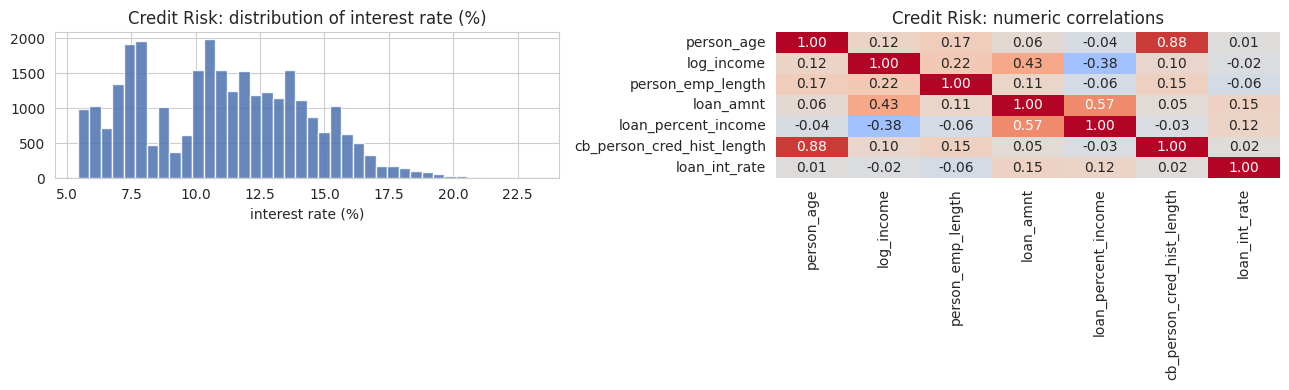

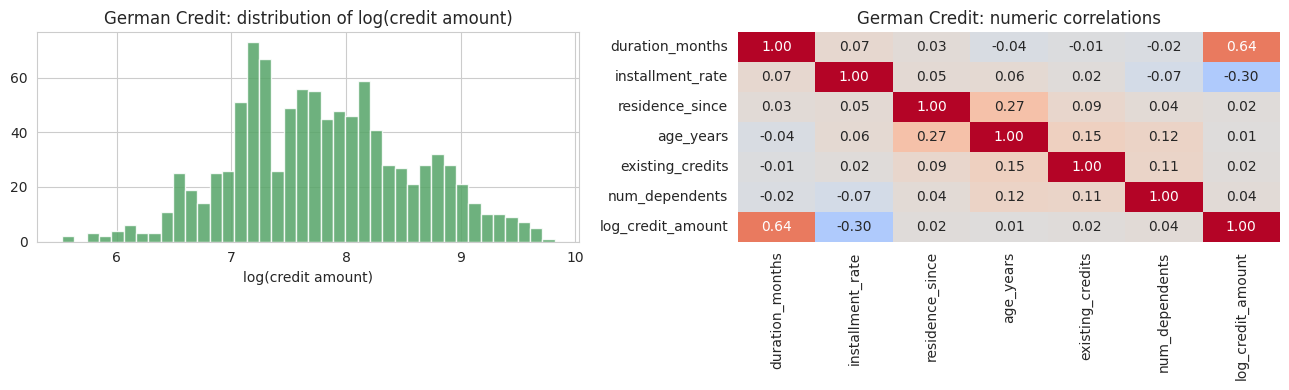

In [2]:
for name in DATASETS:
    d = reg_design(name)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].hist(pd.concat([d['ytr'], d['yte']]), bins=40, color=PALETTE[name], alpha=.85)
    ax[0].set_title(f'{name}: distribution of {d["label"]}'); ax[0].set_xlabel(d['label'])
    corr = d['df'][d['num'] + [d['target']]].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax[1], cbar=False)
    ax[1].set_title(f'{name}: numeric correlations')
    plt.tight_layout(); plt.show()

## 2 · Baseline OLS

In [3]:
RESULTS = {n: [] for n in DATASETS}
def rrep(name, model, A, B, ytr, yte, label):
    RESULTS[name].append({'model':label,'R2_train':round(r2_score(ytr,model.predict(A)),4),
        'R2_test':round(r2_score(yte,model.predict(B)),4),'RMSE_test':round(rmse(yte,model.predict(B)),4)})
for name in DATASETS:
    d = reg_design(name)
    ols = LinearRegression().fit(d['Xtr'], d['ytr'])
    rrep(name, ols, d['Xtr'], d['Xte'], d['ytr'], d['yte'], 'OLS baseline')
    print(f"{name}: OLS test R2 = {RESULTS[name][-1]['R2_test']}, RMSE = {RESULTS[name][-1]['RMSE_test']}")

Credit Risk: OLS test R2 = 0.8695, RMSE = 1.1748
German Credit: OLS test R2 = 0.5966, RMSE = 0.4899


## 3 · Polynomial terms — degree chosen by 5-fold cross-validation (centered)

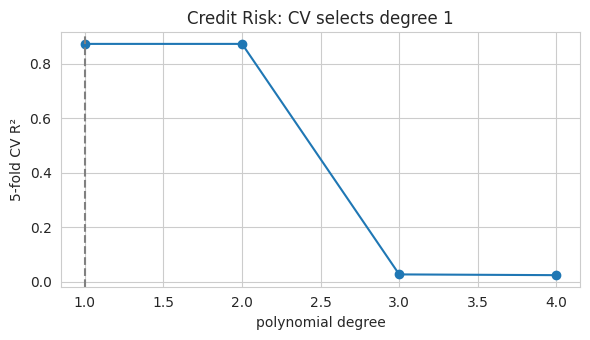

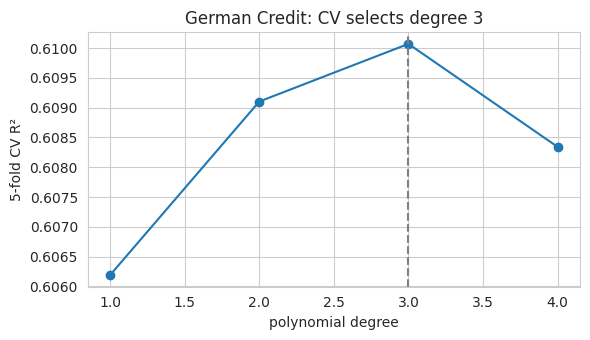

In [4]:
def build_poly(Xin, deg, cols, means):
    Xc = Xin.copy(); blk = {}
    for c in cols:
        x = Xc[c] - means[c]
        for k in range(1, deg+1): blk[f'{c}_c{k}'] = x**k
    Xc = Xc.drop(columns=cols)
    return pd.concat([Xc.reset_index(drop=True), pd.DataFrame(blk).reset_index(drop=True)], axis=1)

for name in DATASETS:
    d = reg_design(name); cols = d['poly']
    rows = []
    for deg in [1, 2, 3, 4]:
        kf = KFold(5, shuffle=True, random_state=RANDOM_STATE); s = []
        for tr, va in kf.split(d['Xtr']):
            m = d['Xtr'].iloc[tr][cols].mean()
            s.append(r2_score(d['ytr'].iloc[va],
                LinearRegression().fit(build_poly(d['Xtr'].iloc[tr],deg,cols,m), d['ytr'].iloc[tr]).predict(build_poly(d['Xtr'].iloc[va],deg,cols,m))))
        rows.append((deg, np.mean(s)))
    best = int(max(rows, key=lambda r: r[1])[0])
    plt.figure(figsize=(6,3.5))
    plt.plot([r[0] for r in rows], [r[1] for r in rows], marker='o')
    plt.axvline(best, ls='--', color='grey'); plt.xlabel('polynomial degree'); plt.ylabel('5-fold CV R²')
    plt.title(f'{name}: CV selects degree {best}'); plt.tight_layout(); plt.show()
    m = d['Xtr'][cols].mean()
    pm = LinearRegression().fit(build_poly(d['Xtr'],best,cols,m), d['ytr'])
    rrep(name, pm, build_poly(d['Xtr'],best,cols,m), build_poly(d['Xte'],best,cols,m), d['ytr'], d['yte'], f'OLS + polynomial (deg={best})')

## 4 · Interaction terms

In [5]:
INTER = {'Credit Risk':('loan_grade_ord','loan_amnt'), 'German Credit':('duration_months','installment_rate')}
for name in DATASETS:
    d = reg_design(name); a,b = INTER[name]
    Xi, Xj = d['Xtr'].copy(), d['Xte'].copy()
    Xi[f'{a}_x_{b}'] = Xi[a]*Xi[b]; Xj[f'{a}_x_{b}'] = Xj[a]*Xj[b]
    im = LinearRegression().fit(Xi, d['ytr'])
    rrep(name, im, Xi, Xj, d['ytr'], d['yte'], f'OLS + interaction ({a}×{b})')
    print(f'{name}: added interaction {a} × {b}')

Credit Risk: added interaction loan_grade_ord × loan_amnt
German Credit: added interaction duration_months × installment_rate


## 5 · Multicollinearity — Variance Inflation Factor on the numeric block

In [6]:
for name in DATASETS:
    d = reg_design(name)
    Xc = sm.add_constant(d['Xtr'][d['num']].astype(float))
    vif = pd.DataFrame({'feature':[c for c in Xc.columns if c!='const'],
        'VIF':[round(variance_inflation_factor(Xc.values,i),2) for i,c in enumerate(Xc.columns) if c!='const']})
    print(f'--- {name} ---'); print(vif.to_string(index=False)); print()

--- Credit Risk ---
                   feature  VIF
                person_age 4.46
                log_income 4.21
         person_emp_length 1.08
                 loan_amnt 5.29
       loan_percent_income 5.00
cb_person_cred_hist_length 4.41

--- German Credit ---
         feature  VIF
 duration_months 1.01
installment_rate 1.01
 residence_since 1.09
       age_years 1.12
existing_credits 1.03
  num_dependents 1.03



## 6 · Model comparison and residual diagnostics

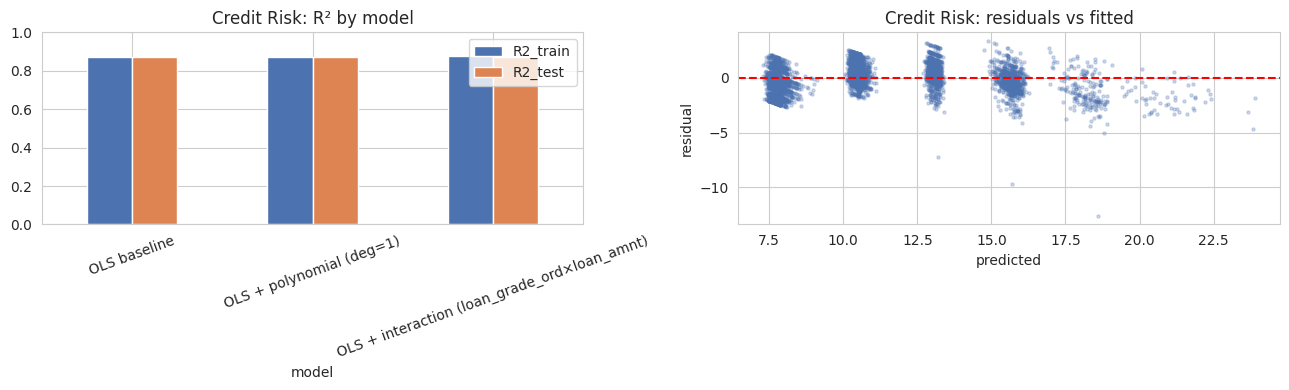

=== Credit Risk ===
                                               R2_train  R2_test  RMSE_test
model                                                                     
OLS baseline                                    0.8738   0.8695     1.1748
OLS + polynomial (deg=1)                        0.8738   0.8695     1.1748
OLS + interaction (loan_grade_ord×loan_amnt)    0.8772   0.8713     1.1668 



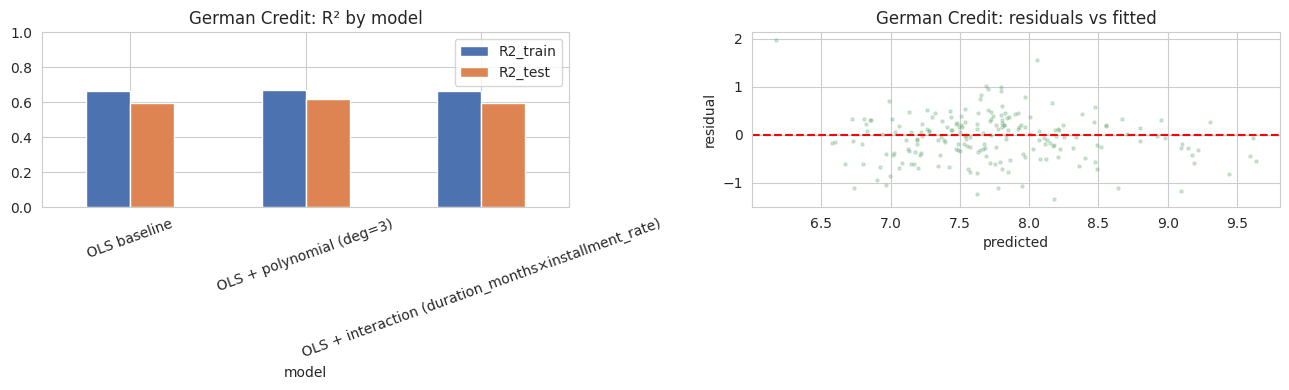

=== German Credit ===
                                                     R2_train  R2_test  \
model                                                                   
OLS baseline                                          0.6621   0.5966   
OLS + polynomial (deg=3)                              0.6706   0.6190   
OLS + interaction (duration_months×installment_...    0.6640   0.5933   

                                                    RMSE_test  
model                                                          
OLS baseline                                           0.4899  
OLS + polynomial (deg=3)                               0.4761  
OLS + interaction (duration_months×installment_...     0.4919   



In [7]:
for name in DATASETS:
    d = reg_design(name)
    rdf = pd.DataFrame(RESULTS[name]).set_index('model')
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    rdf[['R2_train','R2_test']].plot(kind='bar', ax=ax[0], color=['#4c72b0','#dd8452'])
    ax[0].set_title(f'{name}: R² by model'); ax[0].set_ylim(0,1); ax[0].tick_params(axis='x', rotation=20)
    # residuals of the best (last) model = interaction model refit
    a,b = INTER[name]; Xi,Xj = d['Xtr'].copy(), d['Xte'].copy()
    Xi[f'{a}_x_{b}']=Xi[a]*Xi[b]; Xj[f'{a}_x_{b}']=Xj[a]*Xj[b]
    im=LinearRegression().fit(Xi,d['ytr']); resid=d['yte']-im.predict(Xj)
    ax[1].scatter(im.predict(Xj), resid, s=5, alpha=.25, color=PALETTE[name]); ax[1].axhline(0, color='red', ls='--')
    ax[1].set_xlabel('predicted'); ax[1].set_ylabel('residual'); ax[1].set_title(f'{name}: residuals vs fitted')
    plt.tight_layout(); plt.show()
    print(f'=== {name} ===\n', rdf.round(4), '\n')

## 7 · Conclusions

Applying the identical Week 1 toolkit to both datasets surfaces a real contrast. **Credit Risk** is
essentially linear: cross-validation selects polynomial **degree 1**, the interest rate is an almost
perfect linear function of loan grade and a few risk features (test R² ≈ 0.87), and interaction terms add
only a sliver. **German Credit** is mildly non-linear: CV selects a **cubic** on duration/age/installment,
lifting test R² from 0.60 to 0.62, while the duration×installment interaction does not help. The VIF tables
explain why regularization will behave differently next week — Credit Risk carries a collinear
`loan_percent_income` term, whereas the German numeric predictors are nearly orthogonal (all VIF ≈ 1).